In [2]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)
def exp_fitting(x,y, num=2):
    
    if num==2:
        # Calculate integrals
        iy1 = cumtrapz(y, x, initial=0)
        iy2 = cumtrapz(iy1, x, initial=0)


        # Get exponentials lambdas
        Y = np.column_stack((iy1, iy2,  x**2, x, np.ones_like(x)))
        A = pinv(Y) @ y

        lambdas = eig(np.array([[A[0], A[1]], [1, 0]]))[0]
        # print("Lambdas:", lambdas)

        # Get exponentials multipliers
        X = np.column_stack((np.ones_like(x), np.exp(lambdas[0] * x), np.exp(lambdas[1] * x)))
        P = pinv(X) @ y
        # print("Multipliers:", P)
    
    if num==1:
        iy1 = cumtrapz(y, x, initial=0)

        # Get exponentials lambdas
        Y = np.column_stack((iy1, x, np.ones_like(x)))
        A = pinv(Y) @ y

        lambdas = A[0]
        # print("Lambdas:", lambdas)


        # Get exponentials multipliers
        X = np.column_stack((np.ones_like(x), np.exp(lambdas * x)))
        P = pinv(X) @ y
        # print("Multipliers:", P)
    
    return lambdas



/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadynin.mod" "/home/wzl/L

--No graphics will be displayed.


In [3]:
def time_constant_fitting(run_dt, dtime, fE, E = True, passive=True,  loc='50' ):
    
    neuron = h.FScell(morphologyFilename)
    
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("cal", sec=sec):
                sec.gcalbar_cal = 0.
            if h.ismembrane("calc", sec=sec):
                sec.gcabar_calc = 0.
            if h.ismembrane("calcb", sec=sec):
                sec.gcalbar_calcb = 0.
            if h.ismembrane("can", sec=sec):
                sec.gcabar_can = 0.
            if h.ismembrane("cancr", sec=sec):
                sec.gcabar_cancr = 0.
            if h.ismembrane("canin", sec=sec):
                sec.gcalbar_canin = 0.
            if h.ismembrane("car",sec=sec):
                sec.gcabar_car = 0.
            if h.ismembrane("cat",sec=sec):
                sec.gcatbar_cat = 0.
            if h.ismembrane("catcb",sec=sec):
                sec.gcatbar_catcb = 0.
            if h.ismembrane("h",sec=sec):
                sec.gbar_h = 0.
            if h.ismembrane("hcb",sec=sec):
                sec.gbar_hcb = 0.
            if h.ismembrane("hin",sec=sec):
                sec.gbar_hin = 0.
            if h.ismembrane("ican",sec=sec):
                sec.gbar_ican = 0.
            if h.ismembrane("iCcb",sec=sec):
                sec.gkcbar_iCcb = 0.
            if h.ismembrane("iCcr",sec=sec):
                sec.gkcbar_iCcr = 0.
            if h.ismembrane("iCin",sec=sec):
                sec.gkcbar_iCin = 0.
            if h.ismembrane("IKs",sec=sec):
                sec.gKsbar_IKs = 0.  
            if h.ismembrane("IKscb",sec=sec):
                sec.gKsbar_IKscb = 0.
            if h.ismembrane("IKscr", sec=sec):
                sec.gKsbar_IKscr = 0.
            if h.ismembrane("IKsin", sec=sec):
                sec.gKsbar_IKsin = 0.
            if h.ismembrane("kad", sec=sec):
                sec.gkabar_kad = 0.
            if h.ismembrane("kadcr", sec=sec):
                sec.gkabar_kadcr = 0.
            if h.ismembrane("kadin",sec=sec):
                sec.gkabar_kadin = 0.
            if h.ismembrane("kap",sec=sec):
                sec.gkabar_kap = 0.
            if h.ismembrane("kapcb",sec=sec):
                sec.gkabar_kapcb = 0.
            if h.ismembrane("kapin",sec=sec):
                sec.gkabar_kapin = 0.
            if h.ismembrane("kca",sec=sec):
                sec.gbar_kca = 0.
            if h.ismembrane("kcain",sec=sec):
                sec.gbar_kcain = 0.
            if h.ismembrane("iC",sec=sec):
                sec.gkcbar_iC = 0.
            if h.ismembrane("kctin",sec=sec):
                sec.gkcbar_kctin = 0.
            if h.ismembrane("kdr",sec=sec):
                sec.gkdrbar_kdr = 0.
            if h.ismembrane("kdrcb",sec=sec):
                sec.gkdrbar_kdrcb = 0.
            if h.ismembrane("kdrcr",sec=sec):
                sec.gkdrbar_kdrcr = 0.
            if h.ismembrane("kdrin",sec=sec):
                sec.gkdrbar_kdrin = 0.
            if h.ismembrane("Naf",sec=sec):
                sec.gnafbar_Naf = 0.
            if h.ismembrane("Nafcb",sec=sec):
                sec.gnafbar_Nafcb = 0.
            if h.ismembrane("Nafcr",sec=sec):
                sec.gnafbar_Nafcr = 0.
            if h.ismembrane("Nafin",sec=sec):
                sec.gnafbar_Nafin = 0.
            if h.ismembrane("Nafx",sec=sec):
                sec.gnafbar_Nafx = 0.
            if h.ismembrane("Nap",sec=sec):
                sec.gnapbar_Nap = 0.

                
                    
    h.dt = run_dt
    h.tstop = 200.
    h.v_init = -77.
    v_clamp = -77.

    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()

    # attach it to a synapse
        
    syn = h.Exp2Syn(neuron.dend[int(loc)](0.9))
            
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
    else: 
        syn.e = -100.
    # print(syn.e)
        
    stim.number = 1
    stim.start = 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0e-2  # uS
    
    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma[0](0.5))
    vclamp.amp1 = v_clamp
    vclamp.dur2 = h.tstop
    vclamp.amp2 = v_clamp - 20

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        T = 200./run_dt+1
        N = int(10./dtime)
        data = np.zeros((2*N, int(T)))


        for i in range(1, N+1):
            vclamp.dur1 = 100. + i * dtime
            ncstim.weight[0] = 0e-2
            go()
            data[2*(i-1),:] = irec.to_python()  # Assuming irec is a NEURON Vector

            
            ncstim.weight[0] = fE
            go()
            # data[4*(i-1)+2,:] = recv.to_python()  # Assuming recv is a NEURON Vector
            data[2*(i-1)+1,:] = irec.to_python()  # Assuming irec is a NEURON Vector

        # np.savetxt("neuron_voltage.txt", data)
        # print("Done data!")
        I_w_ng = data[::2, :]
        I_w_g = data[1::2, :]
        diff_I = I_w_ng - I_w_g
        x = np.arange(0.1, 10.1, dtime) # ms
        y = -np.sum(diff_I, axis=1)  # size of 100

        result_lambdas = exp_fitting(x, y, num=2)
        # ground_truth = np.array([-1., -0.2])
        # relative_error = np.abs((result_lambdas - ground_truth)/ground_truth)
        return result_lambdas
    
    
    result_lambdas = main()
    return result_lambdas

# strength

In [3]:
# Your existing functions and code
def time_constant_fitting_parallel(args,):
    fE0, = args
    estimated_lambda  = time_constant_fitting(
        0.1, 0.1, fE0, E = True, block='', name='', 
        loc=1)
    
    
    return estimated_lambda

fE = np.linspace(1e-4, 1e-3, 50)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 50
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(fE0,) for fE0 in fE]

    # Apply the function in parallel
    results = pool.map(time_constant_fitting_parallel, args_list)

# Process the results
estimated_lambdas = np.zeros((len(fE), 2))
for i, result in enumerate(results):
    estimated_lambdas[i, :]= result
    
np.savetxt("estimated_lambdas_active_loc1_fE.txt", estimated_lambdas)


Opening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmenta

# location|

In [4]:
estimated_lambda  = time_constant_fitting(
        0.1, 0.1, 3e-3, E = False, passive=True,
        loc=50)

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


KeyboardInterrupt: 

In [5]:
# Your existing functions and code
def time_constant_fitting_parallel(args,):
    loc0, = args
    estimated_lambda  = time_constant_fitting(
        0.1, 0.1, 3e-3, E = False, passive=True,
        loc=loc0)
    
    return estimated_lambda

loc=np.arange(0, 68, 1)
loc.astype(int)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 50
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(time_constant_fitting_parallel, args_list)

# Process the results
estimated_lambda = np.zeros((len(loc), 2))
for i, result in enumerate(results): 
    estimated_lambda[i, :] = result
    
np.savetxt("estimated_lambdas_passive_dendloc68_fI3e3.txt", estimated_lambda)

Opening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hocOpening gjhuiOpening gjhuiOpening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/exper

/tmp/ipykernel_2578304/2455952677.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  estimated_lambda[i, :] = result


In [ ]:
estimated_lambdas = np.loadtxt("estimated_lambdas_active_loc50_fE.txt")

fE = np.linspace(1e-4, 1e-3, 50)
fig, ax2 = plt.subplots(1,3, figsize = (12,3))
plot_curve(ax2[0], fE, -1./estimated_lambdas[:,0], color='steelblue', title='E synapse, active apic[27] block Ih' + r'$g_{SKv3_1}=0.766$' , xlim=[0,1e-3],ylim=[0,15],dy=5, alpha = 1.0, xlabel=r'$f_{E}/\mu S$', ylabel = r'$\tau$', label='rise time constant')
plot_curve(ax2[0], fE, -1./estimated_lambdas[:,1], color='darkred', title='', xlim=[0,1e-3], dx=5e-4, ylim=[0,15], dy=5., alpha = 1.0, xlabel=r'$f_{E}/\mu S$', ylabel = r'$\tau$', label='decay time constant')
ax2[0].axhline(y=1, color='steelblue', linestyle='--', linewidth=1)
ax2[0].axhline(y=5, color='darkred', linestyle='--', linewidth=1)
# ax2[0].set_title('apic[27] block Ih' + r'$g_{SKv3_1}=0.766$', fontsize=10, weight='bold')
plt.tight_layout()


Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


KeyboardInterrupt: 

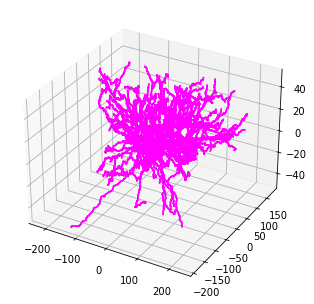

In [9]:
from matplotlib import pyplot, cm
neuron = h.FScell(morphologyFilename)

ps = h.PlotShape(True)
ax = ps.plot(pyplot)
# 将神经元图的线条颜色更改为黑色
for line in ax.lines:
    line.set_color('black')

sec0=neuron.soma[0]
ax.scatter([(sec0.x3d(0)+sec0.x3d(1))/2], 
           [(sec0.y3d(0)+sec0.y3d(1))/2],
           [(sec0.z3d(0)+sec0.z3d(1))/2], 
            color='red', s=20, marker='o', label='soma')



sec=neuron.dend[1]
ax.scatter([(sec.x3d(0)+sec.x3d(1))/2], [(sec.y3d(0)+sec.y3d(1))/2],
            [(sec.z3d(0)+sec.z3d(1))/2], 
            color='green', s=20, marker='o', label='dend 1')



sec1=neuron.dend[50]
ax.scatter([(sec1.x3d(0)+sec1.x3d(1))/2], [(sec1.y3d(0)+sec1.y3d(1))/2],
            [(sec1.z3d(0)+sec1.z3d(1))/2], 
            color='blue', s=20, marker='o', label='dend 50')

# # # # 设置坐标轴范围
# ax.set_xlim([-300, 100])  # 替换 xmin 和 xmax 为所需的 x 范围
# ax.set_ylim([200, 600])  # 替换 ymin 和 ymax 为所需的 y 范围
# ax.set_zlim([-300, 100])  # 替换 zmin 和 zmax 为所需的 z 范围
# 关闭网格
# ax.grid(False)
# 关闭坐标轴
# ax.axis('off')
ax.legend(loc='best',prop=font2,edgecolor='white')
pyplot.show()